# Physical heat fields in 1D and 2D

The heat equation ∂T/∂t=κΔT evolves temperature. Cosine modes on [0,1] with zero normal derivative decay exponentially. This example has an explicit PDE, reflecting boundaries, and time dependence; generic random blobs elsewhere are only spatial surrogates.

**Objective:** reconstruct an analytic physical field using linear sensors and inspect loss of contrast with time.

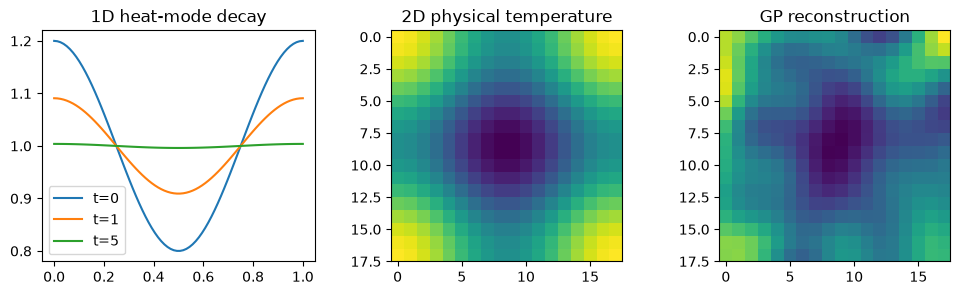

In [1]:
from pathlib import Path
import os
if Path.cwd().name=='tutorials': os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt
from fieldlab import Grid,points,gaussian_process
from fieldlab.fields import heat_field,sensor_layout
from fieldlab.operators import observe
grid1=Grid((80,)); x=grid1.coordinates[:,0]
fig,axes=plt.subplots(1,3,figsize=(12,3))
for t in [0,1,5]: axes[0].plot(x,heat_field(grid1,t),label=f't={t}')
axes[0].legend(); axes[0].set_title('1D heat-mode decay')
grid=Grid((18,18)); truth=heat_field(grid,time=1)
A,_=sensor_layout(grid,seed=50); y=observe(A,truth,.03,51)
# Center by the known equilibrium 1 before applying zero-mean GP.
r=gaussian_process(grid,A,y-A@np.ones(grid.size),noise=.03)
axes[1].imshow(truth); axes[1].set_title('2D physical temperature')
axes[2].imshow(r.mean+1); axes[2].set_title('GP reconstruction')
plt.show()
assert np.ptp(heat_field(grid,5))<np.ptp(heat_field(grid,0))

**Exercise:** verify ∂T/∂t=κΔT analytically. Change diffusivity and sensor density. Explain why a known equilibrium mean improves GP inference. Add a source term or nonzero-flux boundary only after changing the mathematical model.